# Paper figures — Over-Refusal Is Benchmark-Conditional

Regenerates every data figure in the IEEE paper.

**Outputs** (drop into Overleaf under `figures/`):

| file | figure |
|---|---|
| `fig_divergence.pdf` | Fig. 1 — the two benchmarks moving in opposite directions |
| `fig_pareto.pdf` | Fig. 2 — recall vs over-refusal trade-off curve |
| `fig_forest.pdf` | Fig. 3 — paired bootstrap deltas with 95% CIs |
| `fig_corpus.pdf` | optional — training corpus class balance |

Numbers are pasted from `data/benchmark_audit/*.json` so the notebook runs
standalone (no models, no MongoDB, no network). Re-derive them with
`scripts/eval_harmaug.py` if the experiments are re-run.

PDF is used rather than PNG: LaTeX embeds vector output, so the figures stay
sharp at any zoom and the text matches the paper's font weight.

In [1]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

OUT = Path('../paper/figures')
OUT.mkdir(parents=True, exist_ok=True)

# ── Publication styling ─────────────────────────────────────────────────────
# Serif type at ~8pt matches IEEEtran body copy, so figure text does not look
# transplanted. Thin spines and no top/right frame is the convention in the
# venues this targets.
mpl.rcParams.update({
    'figure.dpi':        160,
    'savefig.dpi':       600,
    'savefig.bbox':      'tight',
    'savefig.pad_inches': 0.02,
    'font.family':       'serif',
    'font.serif':        ['DejaVu Serif', 'Times New Roman', 'Nimbus Roman'],
    'font.size':          8,
    'axes.titlesize':     8.5,
    'axes.labelsize':     8,
    'xtick.labelsize':    7.5,
    'ytick.labelsize':    7.5,
    'legend.fontsize':    7.5,
    'axes.linewidth':     0.6,
    'grid.linewidth':     0.4,
    'lines.linewidth':    1.1,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'pdf.fonttype':       42,   # embed TrueType — required by most publishers
    'ps.fonttype':        42,
})

# Muted, colour-blind-safe, and legible in greyscale print — the three things
# a camera-ready figure actually needs. Deliberately desaturated: saturated
# primaries read as a slide deck, not a paper.
C = {
    'base':      '#4C6A92',   # slate blue   — untreated baseline
    'harmaug':   '#C1666B',   # muted rose   — harmful augmentation
    'harmcap':   '#E0A458',   # ochre        — capped variant
    'benign':    '#5B8C7B',   # sage green   — benign augmentation
    'ink':       '#22252A',
    'grid':      '#C9CDD4',
    'rule':      '#8A9099',
}
MODELS   = ['base', 'harmaug', 'harmcap', 'benign']
PRETTY   = {'base': 'Base', 'harmaug': '+HarmAug',
            'harmcap': '+HarmAug$_{cap}$', 'benign': '+BenignAug'}
print('style ready ->', OUT.resolve())

style ready -> C:\Users\ASUS\Desktop\Failure_Intelligence_System\paper\figures


In [2]:
# ── Measured results ────────────────────────────────────────────────────────
# (rate, ci_low, ci_high) as percentages. Source: eval_harmaug.py, fixed
# threshold 0.50, PAIR-isolated, 10,000 paired bootstrap resamples, seed 42.

RATES = {
    'XSTest safe':      {'base': (52.8, 46.4, 58.8), 'harmaug': (48.8, 42.8, 55.2),
                         'harmcap': (46.8, 40.8, 52.8), 'benign': (50.0, 44.0, 56.4)},
    'OR-Bench-hard':    {'base': (90.4, 86.4, 94.0), 'harmaug': (95.6, 92.8, 98.0),
                         'harmcap': (94.0, 90.8, 96.8), 'benign': (88.4, 84.4, 92.0)},
    'HarmBench':        {'base': (84.2, 80.6, 87.9), 'harmaug': (89.1, 85.8, 92.0),
                         'harmcap': (88.6, 85.5, 91.7), 'benign': (87.6, 84.2, 90.7)},
    'StrongREJECT':     {'base': (89.7, 85.5, 93.4), 'harmaug': (95.0, 92.1, 97.5),
                         'harmcap': (94.2, 91.3, 97.1), 'benign': (88.4, 84.3, 92.2)},
    'Held-out attacks': {'base': (89.3, 84.5, 93.5), 'harmaug': (87.5, 82.1, 92.3),
                         'harmcap': (87.5, 82.1, 92.3), 'benign': (82.7, 76.8, 88.1)},
}

N = {'XSTest safe': 250, 'OR-Bench-hard': 250, 'HarmBench': 387,
     'StrongREJECT': 242, 'Held-out attacks': 168}

# Paired differences vs the stated reference: (delta_pts, ci_lo, ci_hi, significant)
DELTA_VS_BASE = {
    'HarmBench':        (+4.9, +2.6, +7.2, True),
    'StrongREJECT':     (+5.4, +2.9, +7.9, True),
    'Held-out attacks': (-1.8, -5.4, +1.8, False),
    'XSTest safe':      (-4.0, -7.6, -0.4, True),
    'OR-Bench-hard':    (+5.2, +2.4, +8.0, True),
}
DELTA_VS_HARMAUG = {
    'HarmBench':        (-1.6, -3.6, +0.5, False),
    'StrongREJECT':     (-6.6, -9.9, -3.3, True),
    'Held-out attacks': (-4.8, -9.5,  0.0, False),
    'XSTest safe':      (+1.2, -2.8, +5.6, False),
    'OR-Bench-hard':    (-7.2, -10.8, -4.0, True),
}
print('data loaded')

data loaded


## Fig. 1 — `fig_divergence.pdf`

The paper's central claim in one image: the same four models, the two
over-refusal benchmarks, opposite directions. Two panels rather than one axis
because the benchmarks sit at very different absolute rates (≈50% vs ≈90%) — a
shared axis would compress OR-Bench's movement into invisibility.

wrote fig_divergence.pdf


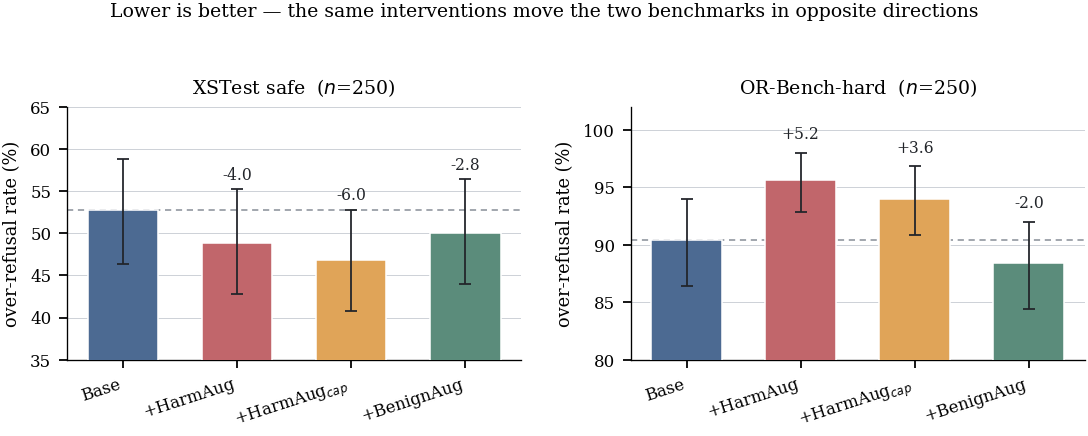

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.7))

for ax, bench in zip(axes, ['XSTest safe', 'OR-Bench-hard']):
    vals = RATES[bench]
    x = np.arange(len(MODELS))
    heights = [vals[m][0] for m in MODELS]
    lo = [vals[m][0] - vals[m][1] for m in MODELS]
    hi = [vals[m][2] - vals[m][0] for m in MODELS]
    cols = [C['base'], C['harmaug'], C['harmcap'], C['benign']]

    ax.bar(x, heights, color=cols, width=0.62, zorder=3,
           edgecolor='white', linewidth=0.7)
    ax.errorbar(x, heights, yerr=[lo, hi], fmt='none', ecolor=C['ink'],
                elinewidth=0.8, capsize=2.5, capthick=0.8, zorder=4)

    # Baseline reference so the direction of every bar is readable at a glance.
    ax.axhline(vals['base'][0], color=C['rule'], ls=(0, (4, 3)),
               lw=0.7, zorder=2)

    for xi, m in zip(x, MODELS):
        d = vals[m][0] - vals['base'][0]
        if m == 'base':
            continue
        ax.annotate(f'{d:+.1f}', (xi, vals[m][2] + 1.2), ha='center',
                    fontsize=7, color=C['ink'])

    ax.set_xticks(x)
    ax.set_xticklabels([PRETTY[m] for m in MODELS], rotation=18, ha='right')
    ax.set_title(f'{bench}  ($n$={N[bench]})')
    ax.set_ylabel('over-refusal rate (%)')
    ax.grid(axis='y', color=C['grid'], zorder=0)
    ax.set_axisbelow(True)

axes[0].set_ylim(35, 65)
axes[1].set_ylim(80, 102)

fig.suptitle('Lower is better — the same interventions move the two benchmarks '
             'in opposite directions', fontsize=8.5, y=1.04)
fig.tight_layout()
fig.savefig(OUT / 'fig_divergence.pdf')
fig.savefig(OUT / 'fig_divergence.png', dpi=400)
print('wrote fig_divergence.pdf')
plt.show()

## Fig. 2 — `fig_pareto.pdf`

Recall against over-refusal, drawn twice: once per over-refusal benchmark.
Side by side, the point is unavoidable — which model looks best depends on
which benchmark is on the x-axis.

wrote fig_pareto.pdf


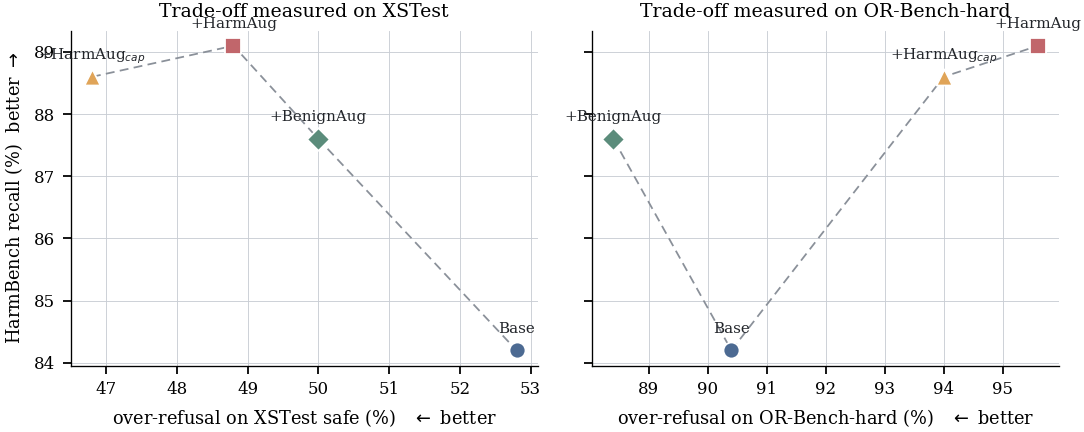

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.9), sharey=True)
MARK = {'base': 'o', 'harmaug': 's', 'harmcap': '^', 'benign': 'D'}
COL  = {'base': C['base'], 'harmaug': C['harmaug'],
        'harmcap': C['harmcap'], 'benign': C['benign']}

for ax, bench in zip(axes, ['XSTest safe', 'OR-Bench-hard']):
    xs = [RATES[bench][m][0] for m in MODELS]
    ys = [RATES['HarmBench'][m][0] for m in MODELS]

    # Connect in order of over-refusal so the trade-off reads as a curve.
    order = np.argsort(xs)
    ax.plot(np.array(xs)[order], np.array(ys)[order], color=C['rule'],
            lw=0.8, ls=(0, (5, 3)), zorder=1)

    for m in MODELS:
        ax.scatter(RATES[bench][m][0], RATES['HarmBench'][m][0],
                   marker=MARK[m], s=52, color=COL[m], edgecolor='white',
                   linewidth=0.8, zorder=3, label=PRETTY[m])
        ax.annotate(PRETTY[m],
                    (RATES[bench][m][0], RATES['HarmBench'][m][0]),
                    textcoords='offset points', xytext=(0, 8),
                    ha='center', fontsize=6.8, color=C['ink'])

    ax.set_xlabel(f'over-refusal on {bench} (%)   $\\leftarrow$ better')
    ax.grid(color=C['grid'], zorder=0)
    ax.set_axisbelow(True)

axes[0].set_ylabel('HarmBench recall (%)  better $\\rightarrow$')
axes[0].set_title('Trade-off measured on XSTest')
axes[1].set_title('Trade-off measured on OR-Bench-hard')
fig.tight_layout()
fig.savefig(OUT / 'fig_pareto.pdf')
fig.savefig(OUT / 'fig_pareto.png', dpi=400)
print('wrote fig_pareto.pdf')
plt.show()

## Fig. 3 — `fig_forest.pdf`

Forest plot of the paired bootstrap differences. This is the figure a reviewer
will look at hardest, because it shows significance rather than asserting it:
an interval crossing zero is not an effect.

wrote fig_forest.pdf


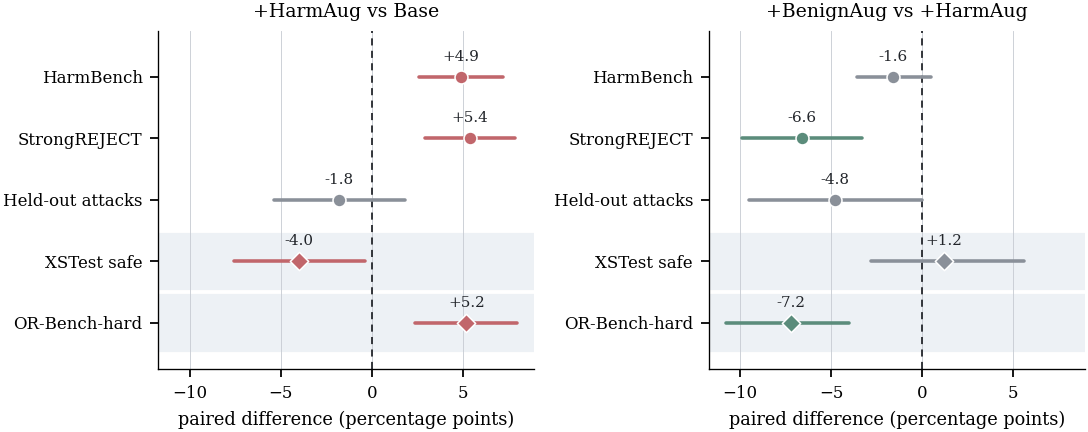

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.9), sharex=True)
ORDER = ['HarmBench', 'StrongREJECT', 'Held-out attacks',
         'XSTest safe', 'OR-Bench-hard']

panels = [('+HarmAug vs Base', DELTA_VS_BASE, C['harmaug']),
          ('+BenignAug vs +HarmAug', DELTA_VS_HARMAUG, C['benign'])]

for ax, (title, deltas, colour) in zip(axes, panels):
    ys = np.arange(len(ORDER))[::-1]
    for y, name in zip(ys, ORDER):
        d, lo, hi, sig = deltas[name]
        is_ovr = name in ('XSTest safe', 'OR-Bench-hard')
        col = colour if sig else C['rule']
        ax.plot([lo, hi], [y, y], color=col, lw=1.6,
                solid_capstyle='round', zorder=3)
        ax.scatter([d], [y], s=34, color=col, zorder=4,
                   marker='D' if is_ovr else 'o',
                   edgecolor='white', linewidth=0.7)
        ax.annotate(f'{d:+.1f}', (d, y + 0.26), ha='center',
                    fontsize=6.8, color=C['ink'])

    # Shade the over-refusal rows so the divergence is findable instantly.
    for y, name in zip(ys, ORDER):
        if name in ('XSTest safe', 'OR-Bench-hard'):
            ax.axhspan(y - 0.45, y + 0.45, color='#EDF1F5', zorder=0)

    ax.axvline(0, color=C['ink'], ls=(0, (4, 3)), lw=0.8, zorder=2)
    ax.set_ylim(-0.75, len(ORDER) - 0.25)   # headroom: keep the top label unclipped
    ax.set_yticks(ys)
    ax.set_yticklabels(ORDER)
    ax.set_title(title)
    ax.set_xlabel('paired difference (percentage points)')
    ax.grid(axis='x', color=C['grid'], zorder=1)
    ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig(OUT / 'fig_forest.pdf')
fig.savefig(OUT / 'fig_forest.png', dpi=400)
print('wrote fig_forest.pdf')
plt.show()

## Optional — `fig_corpus.pdf`

Training corpus class balance. Useful if a reviewer asks whether the effect is
"just" class imbalance; the capped variant exists to answer that.

wrote fig_corpus.pdf


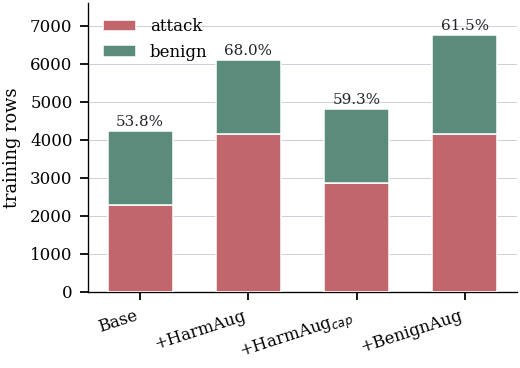

In [6]:
corpora = ['Base', '+HarmAug', '+HarmAug$_{cap}$', '+BenignAug']
rows    = [4236, 6114, 4812, 6761]
atk_pct = [53.8, 68.0, 59.3, 61.5]

fig, ax = plt.subplots(figsize=(3.45, 2.5))
x = np.arange(len(corpora))
atk = [r * p / 100 for r, p in zip(rows, atk_pct)]
ben = [r - a for r, a in zip(rows, atk)]

ax.bar(x, atk, width=0.6, color=C['harmaug'], label='attack',
       edgecolor='white', linewidth=0.7, zorder=3)
ax.bar(x, ben, width=0.6, bottom=atk, color=C['benign'], label='benign',
       edgecolor='white', linewidth=0.7, zorder=3)

for xi, (r, p) in enumerate(zip(rows, atk_pct)):
    ax.annotate(f'{p:.1f}%', (xi, r + 130), ha='center', fontsize=6.8,
                color=C['ink'])

ax.set_xticks(x)
ax.set_xticklabels(corpora, rotation=18, ha='right')
ax.set_ylabel('training rows')
ax.set_ylim(0, 7600)
ax.legend(frameon=False, loc='upper left')
ax.grid(axis='y', color=C['grid'], zorder=0)
ax.set_axisbelow(True)
fig.tight_layout()
fig.savefig(OUT / 'fig_corpus.pdf')
fig.savefig(OUT / 'fig_corpus.png', dpi=400)
print('wrote fig_corpus.pdf')
plt.show()

In [7]:
for f in sorted(OUT.glob('fig_*')):
    print(f'{f.name:26} {f.stat().st_size/1024:7.1f} KB')
print('\nUpload the .pdf files to Overleaf under figures/')

fig_corpus.pdf                15.8 KB
fig_corpus.png                86.7 KB
fig_divergence.pdf            20.7 KB
fig_divergence.png           138.7 KB
fig_forest.pdf                16.3 KB
fig_forest.png               108.2 KB
fig_pareto.pdf                23.2 KB
fig_pareto.png               148.1 KB

Upload the .pdf files to Overleaf under figures/
